In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import StandardScaler
from scipy.optimize import linear_sum_assignment

In [17]:
# Step 1: Load the Iris dataset
iris = load_iris()
X = iris.data
y = iris.target
target_names = iris.target_names

In [18]:
# Step 2: Standardize the features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [19]:
# Step 3: Apply KMeans clustering
kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
kmeans.fit(X_scaled)
labels = kmeans.labels_

In [20]:
# Step 4: Remap cluster labels using Hungarian algorithm
conf_mat = confusion_matrix(y, labels)
row_ind, col_ind = linear_sum_assignment(-conf_mat)
label_mapping = dict(zip(col_ind, row_ind))
mapped_labels = np.array([label_mapping[label] for label in labels])

Confusion Matrix (after remapping):



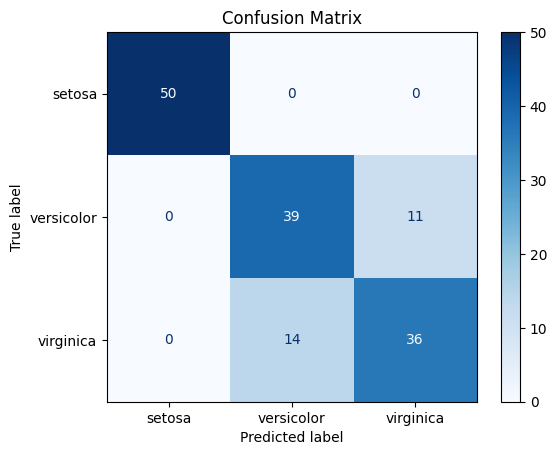

In [21]:
# Step 5: Confusion Matrix (after mapping)
print("Confusion Matrix (after remapping):\n")
disp = ConfusionMatrixDisplay.from_predictions(y, mapped_labels, display_labels=target_names, cmap='Blues')
disp.ax_.set_title("Confusion Matrix")
plt.show()

In [28]:
# Step 6: Classification Report
print("\nClassification Report:")
print(classification_report(y, mapped_labels, target_names=target_names))


Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        50
  versicolor       0.74      0.78      0.76        50
   virginica       0.77      0.72      0.74        50

    accuracy                           0.83       150
   macro avg       0.83      0.83      0.83       150
weighted avg       0.83      0.83      0.83       150



In [29]:
from sklearn.metrics import accuracy_score

accuracy = accuracy_score(y, mapped_labels)
print(f"Model Accuracy: {accuracy:.2f}")


Model Accuracy: 0.83


In [23]:
# Step 7: Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

Text(0, 0.5, 'PCA Component 2')

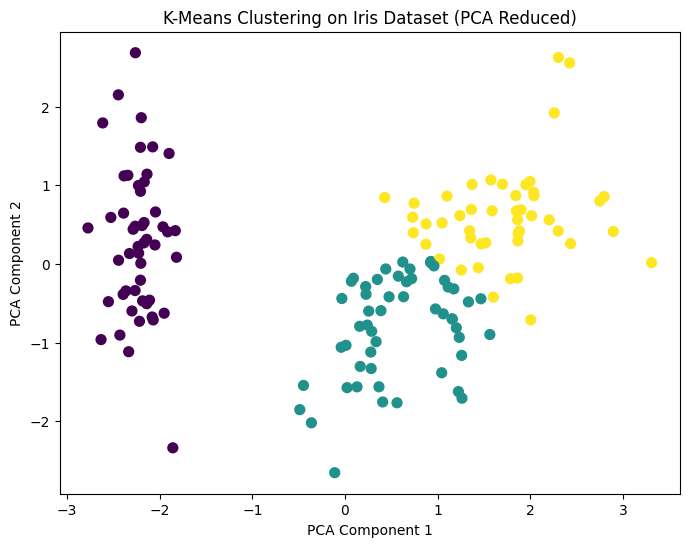

In [26]:
# Step 8: Plot the results
plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=mapped_labels, cmap='viridis', s=50)
plt.title('K-Means Clustering on Iris Dataset (PCA Reduced)')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')

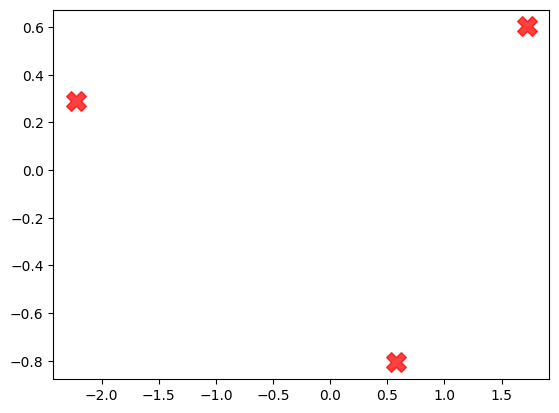

In [27]:
# Mark cluster centers
centers = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers[:, 0], centers[:, 1], c='red', s=200, alpha=0.75, marker='X')
plt.show()

In [32]:

import joblib
from sklearn.preprocessing import StandardScaler

# Fit scaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Save KMeans and Scaler
joblib.dump(kmeans, 'kmeans_model.pkl')
joblib.dump(scaler, 'scaler.pkl')
print ("Model successfully saved as 'kmeans_model.pkl' ")


Model successfully saved as 'kmeans_model.pkl' 
